# Neural Network Anatomy Lab: Live Playground

This is the companion notebook to [the blog post](https://therahulbhati.github.io/posts/nn-from-scratch/). Same order as the post: **Linear → Activation → Stacking → Output/Loss → Backprop → Optimizer → Training loop.**

Dataset: `make_moons`, two interleaving crescents, not linearly separable. It's good for *seeing* why the activation function matters. Without it, no amount of stacked `nn.Linear` layers can bend a straight decision boundary around these moons.

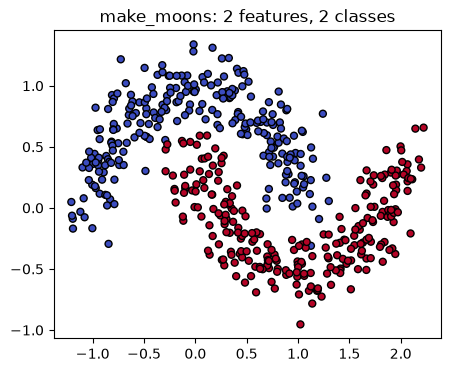

X shape: torch.Size([500, 2]) | y shape: torch.Size([500])


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

torch.manual_seed(0)
np.random.seed(0)

X, y = make_moons(n_samples=500, noise=0.15, random_state=0)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=25)
plt.title("make_moons: 2 features, 2 classes")
plt.show()

print("X shape:", X.shape, "| y shape:", y.shape)

## 01. Linear Layer

`z = Wx + b`. Let's confirm by hand that `nn.Linear` is doing exactly the dot-product-plus-bias math, nothing more.

In [2]:
layer = nn.Linear(in_features=2, out_features=1)

x_sample = X[0]                       # shape (2,)
W, b = layer.weight, layer.bias       # W: (1, 2), b: (1,)

z_manual = W @ x_sample + b           # math convention: W @ x + b
z_pytorch = layer(x_sample)           # nn.Linear does x @ W.T + b internally

print("manual :", z_manual.item())
print("pytorch:", z_pytorch.item())
print("match  :", torch.allclose(z_manual, z_pytorch))

manual : -0.24277886748313904
pytorch: -0.24277886748313904
match  : True


## 02. Activation Function

Plot ReLU, Sigmoid, and Tanh side by side. See the shapes that give each its name.

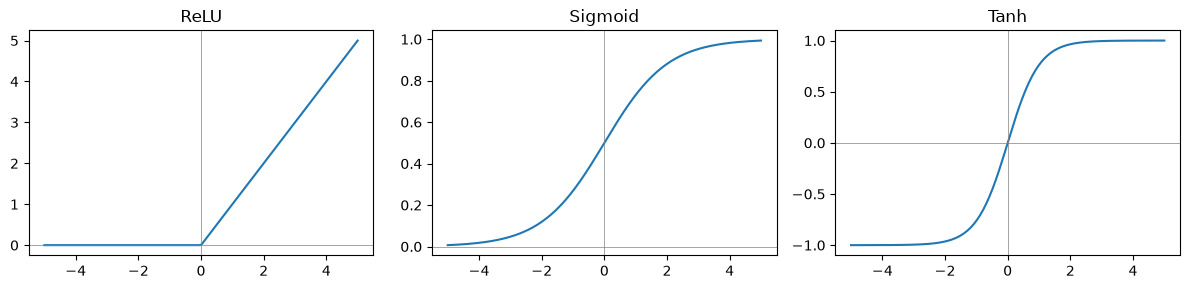

In [3]:
z = torch.linspace(-5, 5, 200)

fns = {"ReLU": torch.relu(z), "Sigmoid": torch.sigmoid(z), "Tanh": torch.tanh(z)}

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, (name, out) in zip(axes, fns.items()):
    ax.plot(z.numpy(), out.numpy())
    ax.set_title(name)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
plt.tight_layout()
plt.show()

## 03. Stacking Layers (MLP)

Two models: one **without** any activation between the linear layers, one **with** ReLU. Watch what each can and can't do to the moons.

In [4]:
def make_model(with_activation: bool, hidden: int = 16):
    if with_activation:
        return nn.Sequential(
            nn.Linear(2, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2),   # 2 logits: class 0 / class 1
        )
    else:
        return nn.Sequential(
            nn.Linear(2, hidden),
            nn.Linear(hidden, hidden),
            nn.Linear(hidden, 2),
        )

linear_only = make_model(with_activation=False)
with_relu = make_model(with_activation=True)
print(linear_only)
print(with_relu)

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): Linear(in_features=16, out_features=16, bias=True)
  (2): Linear(in_features=16, out_features=2, bias=True)
)
Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=2, bias=True)
)


## 04. Output + Loss

Raw logits → softmax probabilities → cross-entropy. Feed `CrossEntropyLoss` the raw logits directly (it applies softmax internally).

In [5]:
loss_fn = nn.CrossEntropyLoss()

logits = with_relu(X[:4])              # (4, 2) raw scores, untrained model
probs = torch.softmax(logits, dim=1)   # (4, 2) rows sum to 1
loss = loss_fn(logits, y[:4])

print("logits:\n", logits.detach())
print("probs (rows sum to 1):\n", probs.detach())
print("loss:", loss.item())

logits:
 tensor([[ 0.0883,  0.0209],
        [ 0.1522,  0.0126],
        [ 0.1092,  0.0120],
        [-0.0293,  0.1458]])
probs (rows sum to 1):
 tensor([[0.5169, 0.4831],
        [0.5349, 0.4651],
        [0.5243, 0.4757],
        [0.4563, 0.5437]])
loss: 0.6944496631622314


## 05. Backpropagation

Before `.backward()`, every parameter's `.grad` is `None`. After it, each has a gradient the same shape as the parameter itself.

In [6]:
model = make_model(with_activation=True)
loss_fn = nn.CrossEntropyLoss()

print("before backward:", model[0].weight.grad)

loss = loss_fn(model(X), y)
loss.backward()

print("after backward, grad shape:", model[0].weight.grad.shape)
print("after backward, grad sample:\n", model[0].weight.grad)

before backward: None


after backward, grad shape: torch.Size([16, 2])
after backward, grad sample:
 tensor([[-1.4201e-03,  4.3855e-04],
        [-2.5535e-03,  5.0186e-04],
        [ 1.3700e-02, -4.8858e-03],
        [ 1.3061e-02, -1.6341e-02],
        [ 6.7272e-03, -4.9225e-04],
        [-1.3772e-05, -6.2637e-05],
        [ 2.8696e-03, -4.9947e-04],
        [-5.0130e-04,  6.3918e-03],
        [-4.8503e-03,  8.0554e-03],
        [-9.9643e-03,  1.0886e-02],
        [ 9.6716e-03, -5.3462e-03],
        [-3.3028e-02,  8.5242e-03],
        [-3.0490e-03,  3.9729e-03],
        [ 4.7998e-03, -5.2151e-03],
        [ 7.1276e-03, -5.6149e-03],
        [-1.7089e-03,  7.2644e-03]])


## 06. Optimizer Step

One manual weight update: `W <- W - lr * grad`, then compare against what `optimizer.step()` does.

In [7]:
lr = 0.1
w_before = model[0].weight.detach().clone()
grad_before = model[0].weight.grad.clone()

optimizer = torch.optim.SGD(model.parameters(), lr=lr)
optimizer.step()          # W <- W - lr * grad, for every parameter

w_after = model[0].weight
w_manual = w_before - lr * grad_before

print("optimizer.step() matches manual update:", torch.allclose(w_after, w_manual))

optimizer.step() matches manual update: True


## 07. Full Training Loop (with live decision boundary)

Train `with_relu` on the moons and plot the decision boundary every 200 epochs. This is the payoff: watch the boundary bend around the two crescents, something a linear-only model can never do.

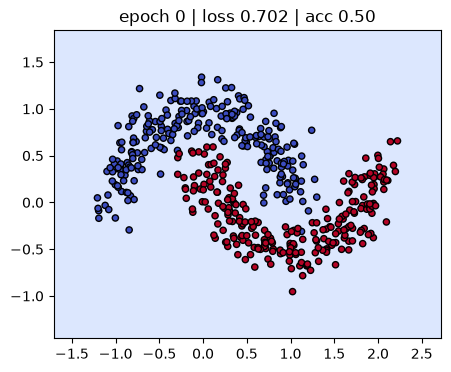

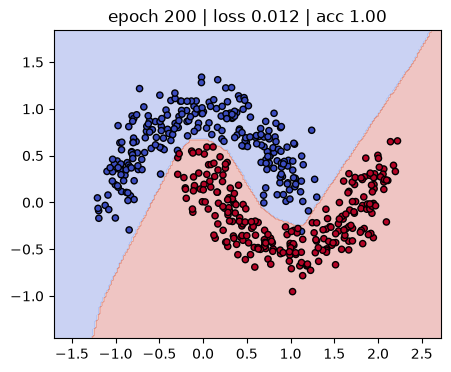

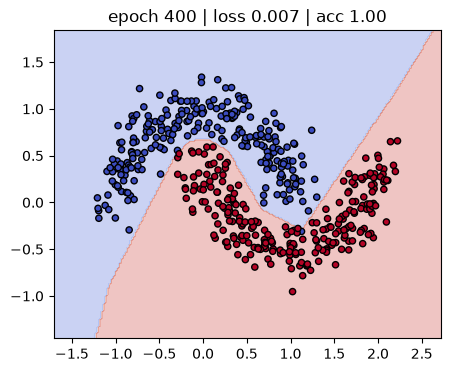

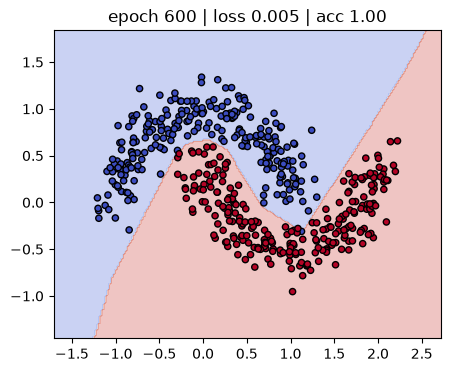

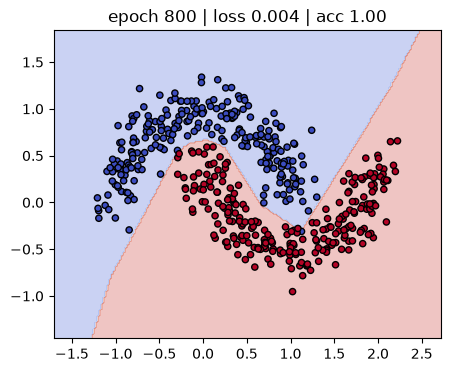

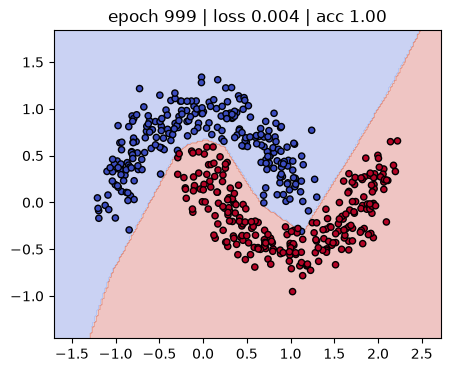

In [8]:
def plot_boundary(model, X, y, title=""):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    with torch.no_grad():
        preds = model(grid).argmax(dim=1).reshape(xx.shape)

    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, preds, alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=20)
    plt.title(title)
    plt.show()


def train(model, X, y, epochs=1000, lr=1e-2, plot_every=200):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        optimizer.step()

        if epoch % plot_every == 0 or epoch == epochs - 1:
            acc = (model(X).argmax(dim=1) == y).float().mean().item()
            plot_boundary(model, X, y, title=f"epoch {epoch} | loss {loss.item():.3f} | acc {acc:.2f}")

    return model


trained_relu = make_model(with_activation=True, hidden=16)
trained_relu = train(trained_relu, X, y, epochs=1000, lr=1e-2, plot_every=200)

### Compare: what happens with no activation function?

Same architecture, same training loop. Just delete the `nn.ReLU()` calls. Expect a straight-line boundary no matter how long you train, because stacked linear layers collapse into one linear layer. See the reasoning in [section 2 of the blog post](https://therahulbhati.github.io/posts/nn-from-scratch/#2-activation-function).

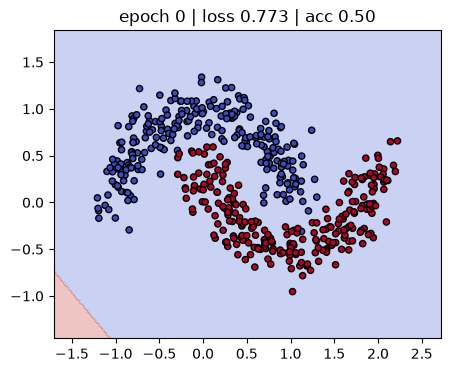

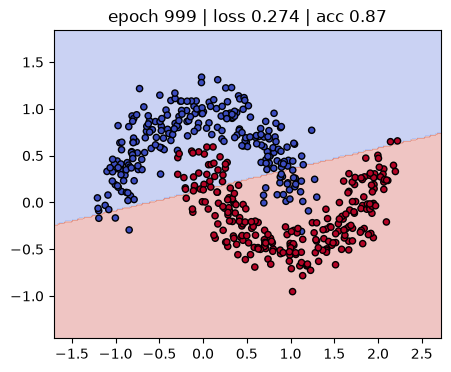

In [9]:
trained_linear = make_model(with_activation=False, hidden=16)
trained_linear = train(trained_linear, X, y, epochs=1000, lr=1e-2, plot_every=1000)

## Play area

Things to try:
- Change `hidden` (width) in `make_model`. How few neurons can still solve the moons?
- Swap `nn.ReLU()` for `nn.Tanh()` or `nn.Sigmoid()` in `make_model`. Does it train faster or slower?
- Change `lr` in `train()`. Too high should make the loss diverge, too low should make it crawl.
- Add `noise=0.3` to `make_moons` above and re-run. Harder separation, watch accuracy drop.

In [10]:
# scratch space, experiment here
